# Volatility targeting: control exposure with an imperfect risk forecast

## Goal

Implement a fixed risk budget, inspect its trading consequences, and identify when realized risk can exceed the target. The constructed shock/reversal path gives **16.97% realized volatility for a 10% target**, compared with **16.10% for a fixed 60% allocation**. This is an intentionally inspectable stress illustration, not a market backtest or an estimate of strategy performance.

[Detailed design and sources](README.md) · [All allocation ideas](../../README.md)

## Setup and assumptions

One risky sleeve, cash earning a hypothetical 3% effective annual rate, 5 basis points per risky dollar traded, initial wealth 100, no leverage and no terminal liquidation. We forecast with 20 observations and delay execution one complete period. Every setting is declared below; no realized-risk normalization or choice of a winning parameter follows the scenario.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/dynamic_exposure.py").exists())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from research.dynamic_exposure import volatility_targets, run_exposure, run_cppi
from research.common import performance
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.18})
BLUE, GOLD, GREY, OLIVE = "#22577a", "#bc6c25", "#555555", "#758e4f"
cash_rate = 1.03 ** (1 / 252) - 1  # hypothetical constant 3% effective annual cash rate

## 1. Build an explicit calm, stress and reversal path

The first 61 observations are forecast history only. Both investment policies start with 100 in cash after that history. The following 180 returns include a −12% shock at investment period 61 and a +14% rebound at period 121. Smooth oscillations between these jumps make the information boundary easy to inspect. These original constructed returns do not represent observed securities or empirical regime frequencies.

In [2]:
warmup = 0.0004 + 0.004 * np.sin(np.arange(61) * 1.3)
calm = 0.0004 + 0.004 * np.sin(np.arange(60) * 1.3)
stress = -0.001 + 0.023 * np.sin(np.arange(60) * 1.3)
reversal = 0.0012 + 0.005 * np.sin(np.arange(60) * 1.3)
stress[0], reversal[0] = -0.12, 0.14
all_returns = np.r_[warmup, calm, stress, reversal]
risky_returns = all_returns[len(warmup):]
policy = volatility_targets(all_returns, lookback=20, target_vol=0.10, cap=1, delay=1)
live_policy = policy.iloc[len(warmup):].reset_index(drop=True)
period = np.arange(1, len(risky_returns) + 1)

## 2. Trade the two declared policies and account for cash

For period `t`, the forecast uses `r[t-21:t-1]`. The weight earning `r[t]` therefore cannot react to that period's return, or to the immediately preceding return. The fixed allocation resets to 60% daily; neither comparator is scaled using the path's realized volatility.

For pretrade risky fraction $u$, desired post-fee fraction $w$ and fee rate $a$, solve $c=a|(1-c)w-u|$. Wealth after trading is $V(1-c)$, and the risky and cash sleeves then earn their respective returns. Turnover below sums absolute risky dollars traded divided by wealth immediately before each trade; 1.0 means trading the equivalent of 100% of contemporaneous capital across the sample.

In [3]:
paths = {
    "10% volatility target": run_exposure(risky_returns, live_policy.target_risky, cash_rate=cash_rate),
    "Fixed 60% risky": run_exposure(risky_returns, np.full(len(period), 0.60), cash_rate=cash_rate),
}
rows = []
for name, path in paths.items():
    result = performance(path.net_return)
    rows.append({"Policy": name, "Mean risky %": 100 * path.target_risky.mean(),
                 "Realized vol %": 100 * result["volatility"],
                 "Max drawdown %": 100 * result["max_drawdown"],
                 "Risky turnover (x)": path.turnover.sum(), "Fees per initial 100": path.fee.sum(),
                 "Terminal wealth": path.wealth_end.iloc[-1]})
display(pd.DataFrame(rows).set_index("Policy").round(3))

,Mean risky %,Realized vol %,Max drawdown %,Risky turnover (x),Fees per initial 100,Terminal wealth
Policy,,,,,,
10% volatility target,68.434,16.974,-12.440,3.404,0.163,100.690
Fixed 60% risky,60.000,16.099,-10.392,0.953,0.047,105.213


## 3. Separate predicted risk from the position that is actually held

The forecast reacts after a shock, then remains elevated until the shock leaves its rolling window. The exposure cap binds during calm observations. A fixed risk budget cannot turn information that arrives after a price move into protection against that same move.

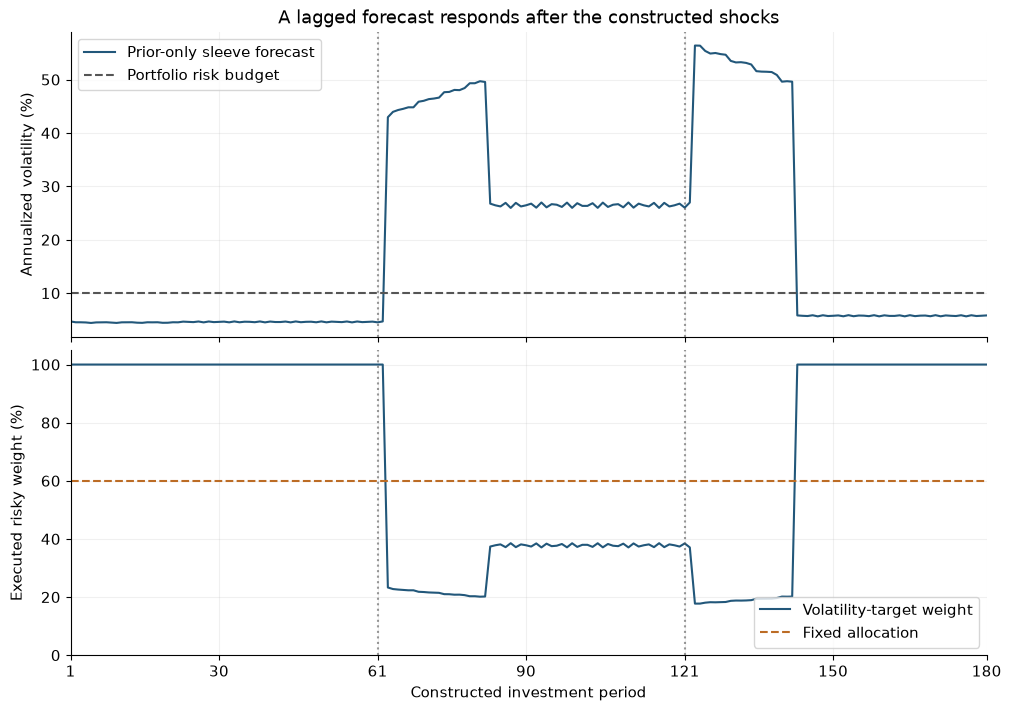

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")
axes[0].plot(period, 100 * live_policy.forecast_vol, color=BLUE, label="Prior-only sleeve forecast")
axes[0].axhline(10, color=GREY, linestyle="--", label="Portfolio risk budget")
axes[0].set(ylabel="Annualized volatility (%)", title="A lagged forecast responds after the constructed shocks")
axes[0].legend(loc="upper left")
axes[1].plot(period, 100 * live_policy.target_risky, color=BLUE, label="Volatility-target weight")
axes[1].axhline(60, color=GOLD, linestyle="--", label="Fixed allocation")
axes[1].set(ylabel="Executed risky weight (%)", xlabel="Constructed investment period", ylim=(0, 105))
axes[1].legend(loc="lower right")
for ax in axes:
    for x in [61, 121]:
        ax.axvline(x, color=GREY, linestyle=":", alpha=0.6)
    ax.set_xlim(1, 180)
    ax.set_xticks([1, 30, 61, 90, 121, 150, 180])
plt.show()

## 4. Inspect wealth and realized risk together

The same sequence that catches the target policy with high exposure before the loss catches it with reduced exposure before the rebound. Over these 180 observations it has more turnover and higher realized volatility than the 60% comparator. The 21-period rolling estimates below are descriptive after the event and never feed back into target calibration. Their gaps at the start mean insufficient observations, not zero risk.

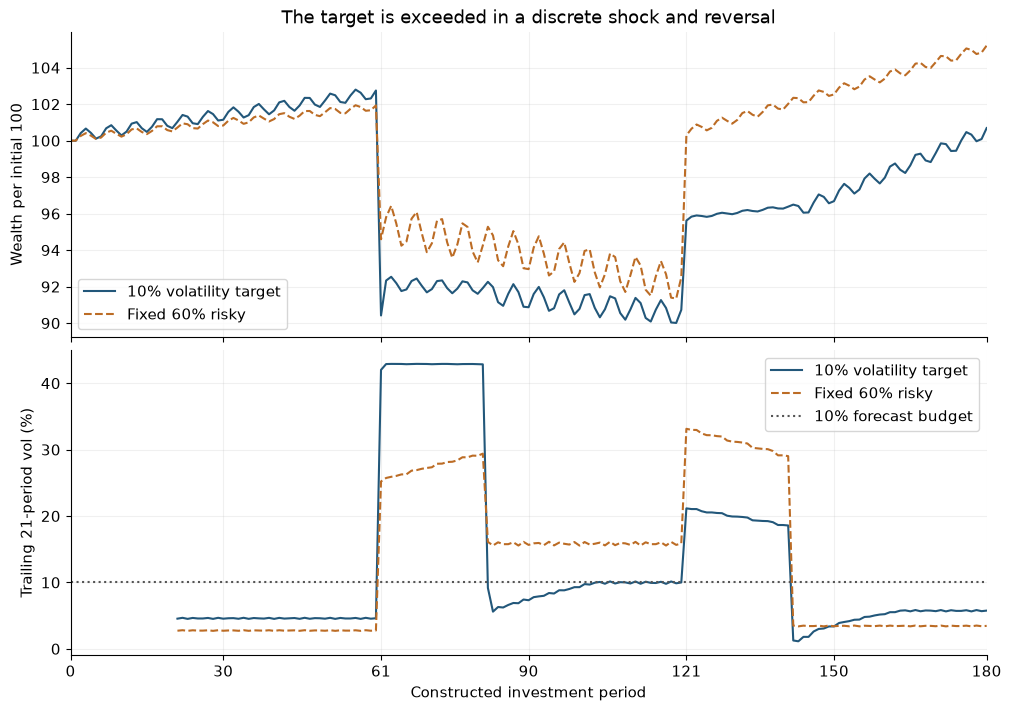

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")
for (name, path), color, style in zip(paths.items(), [BLUE, GOLD], ["-", "--"], strict=True):
    axes[0].plot(np.r_[0, period], np.r_[100, path.wealth_end], color=color, linestyle=style, label=name)
    realized = path.net_return.rolling(21).std(ddof=1) * np.sqrt(252) * 100
    axes[1].plot(period, realized, color=color, linestyle=style, label=name)
axes[0].set(ylabel="Wealth per initial 100", title="The target is exceeded in a discrete shock and reversal")
axes[0].legend(loc="lower left")
axes[1].axhline(10, color=GREY, linestyle=":", label="10% forecast budget")
axes[1].set(ylabel="Trailing 21-period vol (%)", xlabel="Constructed investment period")
axes[1].legend(loc="upper right")
axes[1].set_xlim(0, 180)
axes[1].set_xticks([0, 30, 61, 90, 121, 150, 180])
plt.show()

## 5. Check timing and independently reconcile one trade

Changing return 100 onward must leave every target through period index 101 unchanged: the extra execution delay preserves one more decision beyond the last unchanged observation. The dollar example uses a deliberately visible 1% cash return for one period to test accounting, rather than the scenario's 3% annual cash assumption.

In [6]:
changed = all_returns.copy()
changed[100:] = 0.25
perturbed = volatility_targets(changed, lookback=20, target_vol=0.10, cap=1, delay=1)
np.testing.assert_array_equal(policy.target_risky.iloc[:102], perturbed.target_risky.iloc[:102])
assert (live_policy.target_risky.between(0, 1)).all()
one = run_exposure([0.10], [0.60], cash_rate=0.01, cost_bps=10).iloc[0]
fee = 0.001 * 60 / (1 + 0.001 * 0.60)
risky_dollars, cash_dollars = (100 - fee) * 0.60, (100 - fee) * 0.40
np.testing.assert_allclose(one.fee, fee)
np.testing.assert_allclose(one.wealth_end, risky_dollars * 1.10 + cash_dollars * 1.01)
for path in paths.values():
    np.testing.assert_allclose(path.risky_after_trade + path.cash_after_trade + path.fee, path.wealth_start)
print("Passed: future-information boundary, unlevered cap, independent fee/cash arithmetic, dollar reconciliation.")

Passed: future-information boundary, unlevered cap, independent fee/cash arithmetic, dollar reconciliation.


## Takeaways and next questions

Volatility targeting converts a forecast into an exposure decision. It does not bound realized losses, ensure realized volatility equals the budget, or establish a return premium. In this constructed case the rule suffers from a lagged response and a quick reversal. A useful research extension reports all declared forecast windows, delays, trading bands and costs, and separates lower average exposure from timing effects with prior-only controls.

[Moreira and Muir's primary paper](https://law.yale.edu/sites/default/files/area/workshop/leo/leo17_moreira.pdf), equation (1), motivates the broader study of volatility management using inverse **variance**. This notebook implements a distinct bounded inverse **standard-deviation** target; it neither reproduces their empirical study nor borrows a full-sample normalization. [CPPI](../18-cppi/README.md) instead changes exposure according to a wealth cushion.